In [1]:
# ============================================================
# 1. Load datasets
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from shapely.geometry import Point, Polygon
from shapely.prepared import prep

blast_master_path = "data/blast_master.csv"
block_model_path = "data/block_model_copper.csv"

blast = pd.read_csv(blast_master_path)
blocks = pd.read_csv(block_model_path)

print("Blast master shape:", blast.shape)
print("Block model shape:", blocks.shape)

print("\nBlast master columns:")
print(blast.columns.tolist())

print("\nBlock model columns:")
print(blocks.columns.tolist())

display(blast.head())
display(blocks.head())

Blast master shape: (460, 5)
Block model shape: (5892, 37)

Blast master columns:
['pattern_id', 'pattern_type', 'point_id', 'x', 'y']

Block model columns:
['x', 'y', 'block_id', 'x_m', 'y_m', 'z_top_m', 'z_bottom_m', 'bench_name', 'location', 'oxidation', 'density_tpm3', 'au_gpt', 'cu_pct', 'ag_gpt', 'Axb', 'BWi_kWht', 'DWi_kWhm3', 'UCS_MPa', 'RMR', 'digability', 'sulfides_pct', 'carbonate_pct', 'clays_pct', 'fault_dist_m', 'cn_demand_kgt', 'rec_au', 'rec_cu', 'rec_ag', 'pf_target_kgpm3', 'target_p80_mm', 'wet', 'latitude', 'longitude', 'lithology', 'alteration_domain', 'mineral_domain', 'structure_domain']


,pattern_id,pattern_type,point_id,x,y
0,4,Production,1,363597.883326,6.591692e+06
1,4,Production,2,363575.468019,6.591695e+06
2,4,Production,3,363554.653806,6.591697e+06
3,4,Production,4,363555.585530,6.591706e+06
4,4,Production,5,363564.407712,6.591774e+06


,x,y,block_id,x_m,y_m,z_top_m,z_bottom_m,bench_name,location,oxidation,...,rec_ag,pf_target_kgpm3,target_p80_mm,wet,latitude,longitude,lithology,alteration_domain,mineral_domain,structure_domain
0,363274.918068,6.591392e+06,B_013_007,130.0,-380.0,200.0,185.0,RL185-200,waste,transition,...,0.74,1.00,140,True,-30.802687,121.570820,propylitic_volcanics,propylitic_halo,waste,background
1,363284.918068,6.591392e+06,B_014_007,140.0,-380.0,200.0,185.0,RL185-200,waste,transition,...,0.75,0.98,150,True,-30.802689,121.570925,propylitic_volcanics,propylitic_halo,waste,background
2,363294.918068,6.591392e+06,B_015_007,150.0,-380.0,200.0,185.0,RL185-200,waste,transition,...,0.74,0.94,145,False,-30.802690,121.571029,propylitic_volcanics,propylitic_halo,waste,background
3,363304.918068,6.591392e+06,B_016_007,160.0,-380.0,200.0,185.0,RL185-200,waste,transition,...,0.75,0.96,145,True,-30.802691,121.571134,propylitic_volcanics,propylitic_halo,waste,cross_fault
4,363314.918068,6.591392e+06,B_017_007,170.0,-380.0,200.0,185.0,RL185-200,waste,transition,...,0.72,0.85,155,True,-30.802692,121.571238,propylitic_volcanics,propylitic_halo,waste,cross_fault


In [2]:
# ============================================================
# 2. Check coordinate extents
# ============================================================

def extent_summary(df, x_col, y_col, name):
    return {
        "dataset": name,
        "x_min": df[x_col].min(),
        "x_max": df[x_col].max(),
        "y_min": df[y_col].min(),
        "y_max": df[y_col].max(),
        "x_range": df[x_col].max() - df[x_col].min(),
        "y_range": df[y_col].max() - df[y_col].min(),
    }

extent_df = pd.DataFrame([
    extent_summary(blast, "x", "y", "blast_master_x_y"),
    extent_summary(blocks, "x", "y", "block_model_x_y"),
])

display(extent_df)

# Optional: compare against local block coordinates if present
if {"x_m", "y_m"}.issubset(blocks.columns):
    local_extent_df = pd.DataFrame([
        extent_summary(blast, "x", "y", "blast_master_x_y"),
        extent_summary(blocks, "x_m", "y_m", "block_model_x_m_y_m"),
    ])
    print("\nComparison against block model local coordinates:")
    display(local_extent_df)

,dataset,x_min,x_max,y_min,y_max,x_range,y_range
0,blast_master_x_y,363327.678877,363842.157258,6.591674e+06,6.591939e+06,514.478381,264.774633
1,block_model_x_y,363144.918068,364024.918068,6.591392e+06,6.592222e+06,880.000000,830.000000



Comparison against block model local coordinates:


,dataset,x_min,x_max,y_min,y_max,x_range,y_range
0,blast_master_x_y,363327.678877,363842.157258,6.591674e+06,6.591939e+06,514.478381,264.774633
1,block_model_x_m_y_m,0.000000,880.000000,-3.800000e+02,4.500000e+02,880.000000,830.000000


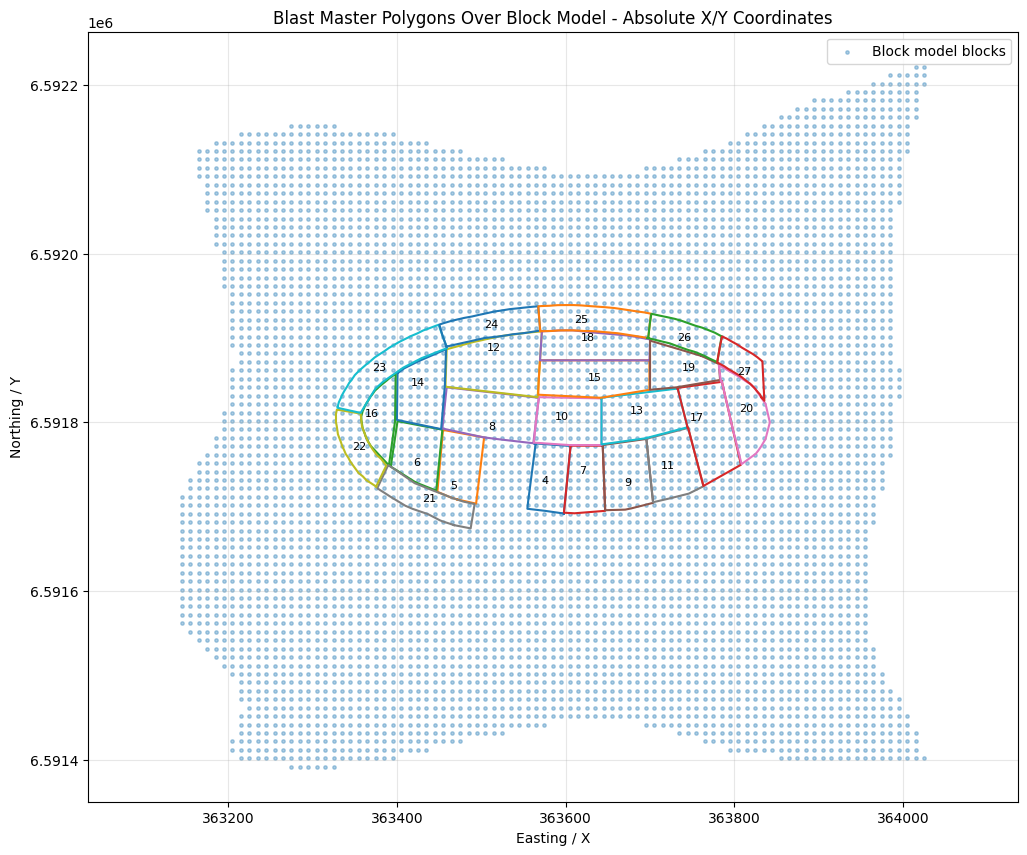

In [3]:
# ============================================================
# 3. Visual overlay: block model points + blast polygons
# ============================================================

plt.figure(figsize=(12, 10))

# Plot block model points
plt.scatter(
    blocks["x"],
    blocks["y"],
    s=6,
    alpha=0.35,
    label="Block model blocks"
)

# Plot blast polygons
for pattern_id, g in blast.sort_values(["pattern_id", "point_id"]).groupby("pattern_id"):
    x = g["x"].values
    y = g["y"].values

    # close polygon visually
    x_closed = np.r_[x, x[0]]
    y_closed = np.r_[y, y[0]]

    plt.plot(x_closed, y_closed, linewidth=1.5)
    plt.text(
        np.mean(x),
        np.mean(y),
        str(pattern_id),
        fontsize=8,
        ha="center",
        va="center"
    )

plt.title("Blast Master Polygons Over Block Model - Absolute X/Y Coordinates")
plt.xlabel("Easting / X")
plt.ylabel("Northing / Y")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

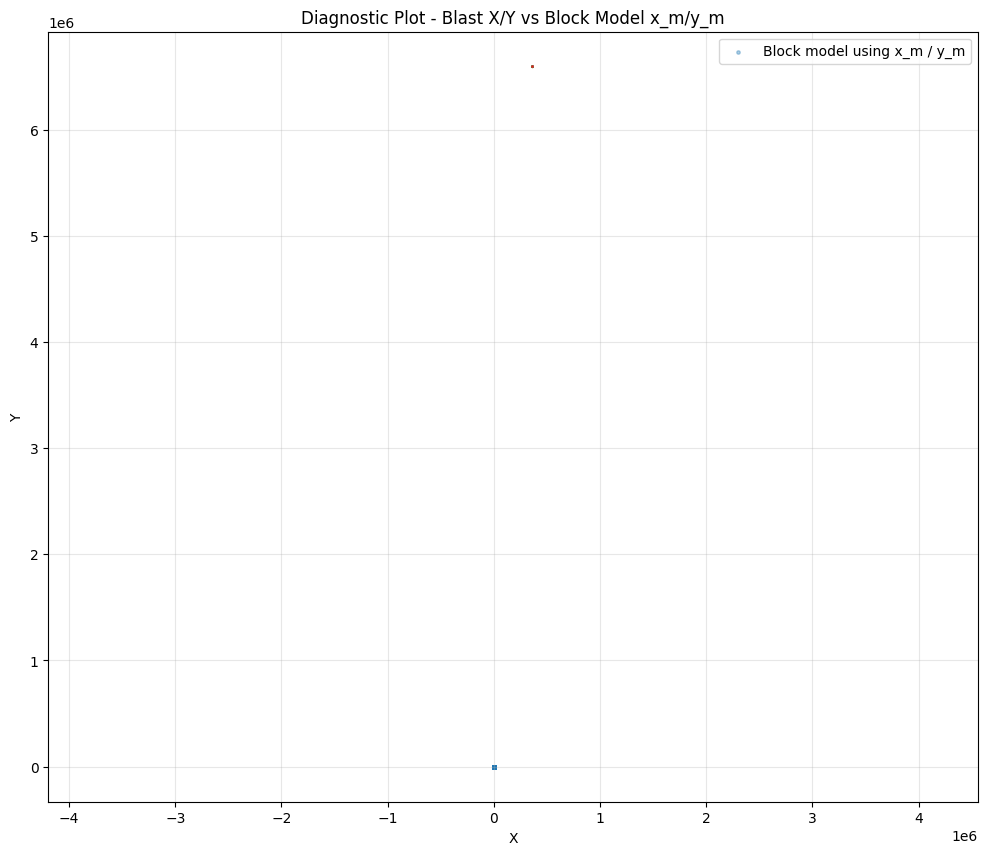

If this plot shows the datasets far apart, then the connector should not be using x_m / y_m for spatial matching against blast polygons.


In [4]:
# ============================================================
# 4. Diagnostic: what happens if the connector is using x_m / y_m?
# ============================================================

if {"x_m", "y_m"}.issubset(blocks.columns):
    plt.figure(figsize=(12, 10))

    plt.scatter(
        blocks["x_m"],
        blocks["y_m"],
        s=6,
        alpha=0.35,
        label="Block model using x_m / y_m"
    )

    for pattern_id, g in blast.sort_values(["pattern_id", "point_id"]).groupby("pattern_id"):
        x = g["x"].values
        y = g["y"].values

        x_closed = np.r_[x, x[0]]
        y_closed = np.r_[y, y[0]]

        plt.plot(x_closed, y_closed, linewidth=1.5)

    plt.title("Diagnostic Plot - Blast X/Y vs Block Model x_m/y_m")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(
        "If this plot shows the datasets far apart, then the connector should not be "
        "using x_m / y_m for spatial matching against blast polygons."
    )

In [5]:
# ============================================================
# 5. Build blast polygons and count blocks inside each pattern
# ============================================================

blast_polygons = {}

for pattern_id, g in blast.sort_values(["pattern_id", "point_id"]).groupby("pattern_id"):
    coords = list(zip(g["x"], g["y"]))

    # close polygon if not already closed
    if coords[0] != coords[-1]:
        coords.append(coords[0])

    poly = Polygon(coords)

    blast_polygons[pattern_id] = {
        "polygon": poly,
        "is_valid": poly.is_valid,
        "area": poly.area,
        "bounds": poly.bounds,
        "n_points": len(g),
    }

rows = []

block_points = [Point(xy) for xy in zip(blocks["x"], blocks["y"])]

for pattern_id, info in blast_polygons.items():
    poly = info["polygon"]
    prepared_poly = prep(poly)

    inside_mask = [
        prepared_poly.contains(pt) or prepared_poly.touches(pt)
        for pt in block_points
    ]

    count_inside = int(np.sum(inside_mask))

    rows.append({
        "pattern_id": pattern_id,
        "blocks_inside": count_inside,
        "polygon_area": info["area"],
        "polygon_valid": info["is_valid"],
        "n_polygon_points": info["n_points"],
        "x_min": info["bounds"][0],
        "y_min": info["bounds"][1],
        "x_max": info["bounds"][2],
        "y_max": info["bounds"][3],
    })

pattern_check = pd.DataFrame(rows).sort_values("blocks_inside")

display(pattern_check)

print("\nPatterns with zero blocks inside:")
display(pattern_check[pattern_check["blocks_inside"] == 0])

print("\nPatterns with low block counts:")
display(pattern_check[pattern_check["blocks_inside"] <= 10])

,pattern_id,blocks_inside,polygon_area,polygon_valid,n_polygon_points,x_min,y_min,x_max,y_max
23,27,18,1910.108516,True,34,363779.734176,6.591826e+06,363835.645686,6.591902e+06
22,26,25,2605.626701,True,30,363697.151113,6.591871e+06,363785.010053,6.591929e+06
18,22,27,2650.497775,True,44,363327.678877,6.591724e+06,363387.339552,6.591815e+06
12,16,29,2778.170632,True,45,363357.720924,6.591749e+06,363398.490603,6.591857e+06
0,4,33,3375.045424,True,9,363554.653806,6.591692e+06,363605.888792,6.591775e+06
17,21,34,3447.174069,True,36,363376.682350,6.591674e+06,363492.085363,6.591749e+06
15,19,34,3338.156849,True,7,363700.100251,6.591839e+06,363783.148963,6.591897e+06
20,24,35,3381.915381,True,28,363450.275207,6.591890e+06,363569.864192,6.591938e+06
3,7,36,3436.488811,True,8,363597.980159,6.591692e+06,363646.919936,6.591772e+06
2,6,36,3608.022152,True,6,363392.674320,6.591719e+06,363453.868107,6.591801e+06



Patterns with zero blocks inside:


,pattern_id,blocks_inside,polygon_area,polygon_valid,n_polygon_points,x_min,y_min,x_max,y_max



Patterns with low block counts:


,pattern_id,blocks_inside,polygon_area,polygon_valid,n_polygon_points,x_min,y_min,x_max,y_max


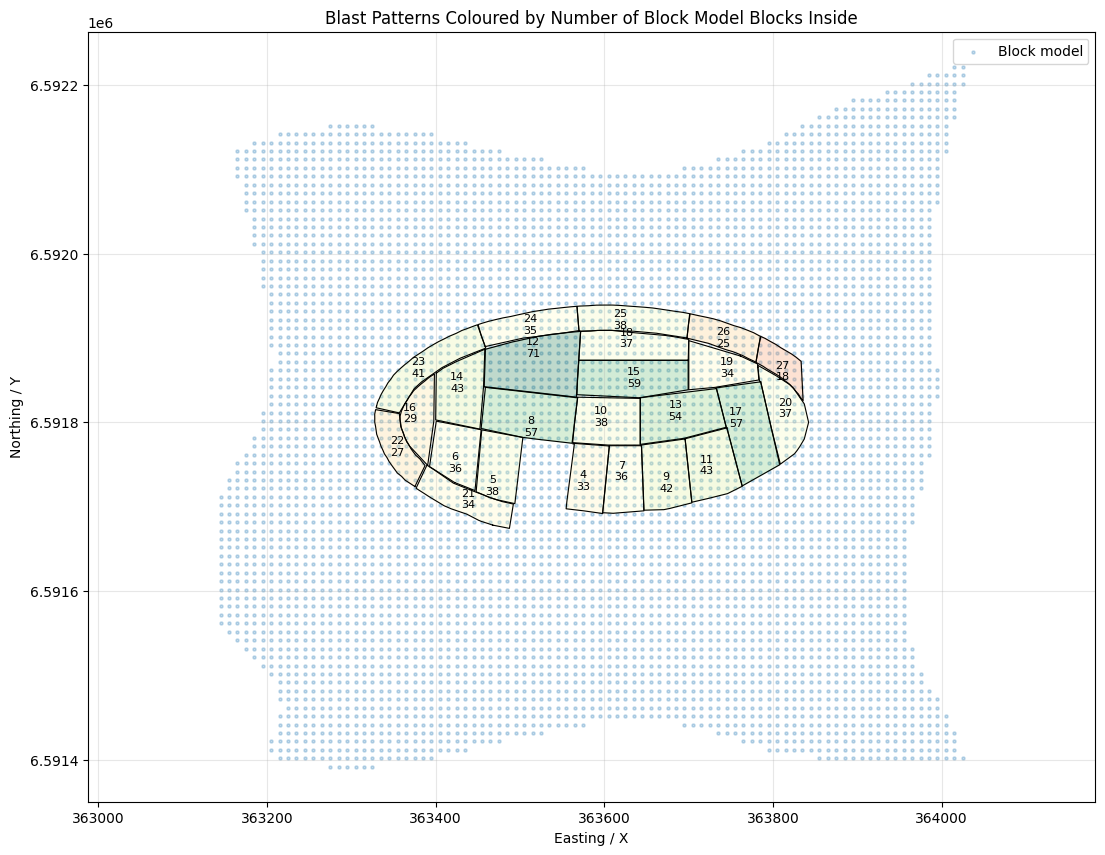

In [6]:
# ============================================================
# 6. Colour polygons by block count
# ============================================================

fig, ax = plt.subplots(figsize=(13, 10))

ax.scatter(
    blocks["x"],
    blocks["y"],
    s=5,
    alpha=0.25,
    label="Block model"
)

max_count = max(pattern_check["blocks_inside"].max(), 1)

for _, row in pattern_check.iterrows():
    pattern_id = row["pattern_id"]
    count = row["blocks_inside"]

    g = blast[blast["pattern_id"] == pattern_id].sort_values("point_id")

    x = g["x"].values
    y = g["y"].values

    x_closed = np.r_[x, x[0]]
    y_closed = np.r_[y, y[0]]

    # Red = low count, green-ish = higher count
    colour_value = count / max_count

    ax.fill(
        x_closed,
        y_closed,
        alpha=0.25,
        color=plt.cm.RdYlGn(colour_value)
    )

    ax.plot(x_closed, y_closed, color="black", linewidth=0.8)

    ax.text(
        np.mean(x),
        np.mean(y),
        f"{int(pattern_id)}\n{int(count)}",
        fontsize=8,
        ha="center",
        va="center"
    )

ax.set_title("Blast Patterns Coloured by Number of Block Model Blocks Inside")
ax.set_xlabel("Easting / X")
ax.set_ylabel("Northing / Y")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

In [7]:
# ============================================================
# 7. Assign each block to a blast pattern
# ============================================================

assigned_blocks = blocks.copy()
assigned_blocks["pattern_id"] = np.nan

for pattern_id, info in blast_polygons.items():
    poly = info["polygon"]
    prepared_poly = prep(poly)

    inside_mask = [
        prepared_poly.contains(Point(x, y)) or prepared_poly.touches(Point(x, y))
        for x, y in zip(assigned_blocks["x"], assigned_blocks["y"])
    ]

    assigned_blocks.loc[inside_mask, "pattern_id"] = pattern_id

print("Blocks assigned to a blast pattern:", assigned_blocks["pattern_id"].notna().sum())
print("Blocks not assigned to any blast pattern:", assigned_blocks["pattern_id"].isna().sum())

assigned_summary = (
    assigned_blocks
    .dropna(subset=["pattern_id"])
    .groupby("pattern_id")
    .size()
    .reset_index(name="block_count")
    .sort_values("block_count")
)

display(assigned_summary)

Blocks assigned to a blast pattern: 962
Blocks not assigned to any blast pattern: 4930


,pattern_id,block_count
23,27.0,18
22,26.0,25
18,22.0,27
12,16.0,29
0,4.0,33
17,21.0,34
15,19.0,34
20,24.0,35
3,7.0,36
2,6.0,36


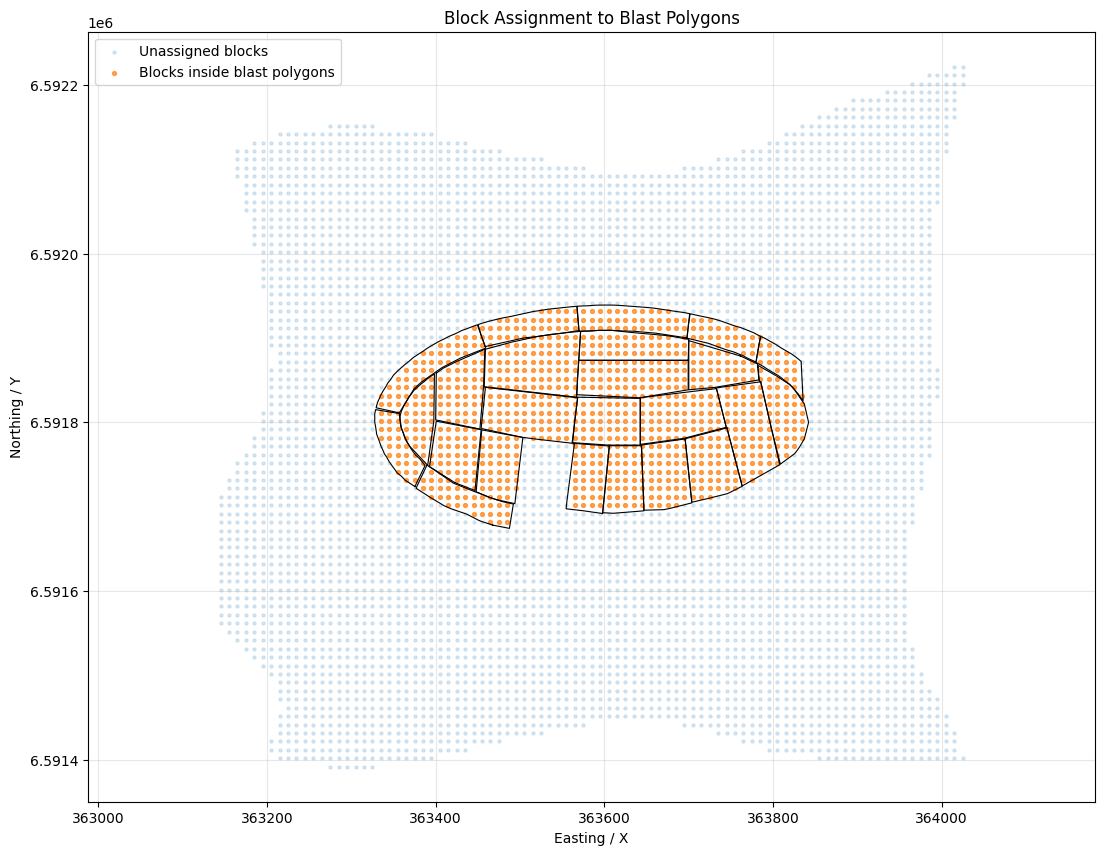

In [8]:
# ============================================================
# 8. Plot assigned vs unassigned blocks
# ============================================================

fig, ax = plt.subplots(figsize=(13, 10))

assigned = assigned_blocks[assigned_blocks["pattern_id"].notna()]
unassigned = assigned_blocks[assigned_blocks["pattern_id"].isna()]

ax.scatter(
    unassigned["x"],
    unassigned["y"],
    s=5,
    alpha=0.15,
    label="Unassigned blocks"
)

ax.scatter(
    assigned["x"],
    assigned["y"],
    s=8,
    alpha=0.7,
    label="Blocks inside blast polygons"
)

for pattern_id, g in blast.sort_values(["pattern_id", "point_id"]).groupby("pattern_id"):
    x = g["x"].values
    y = g["y"].values

    ax.plot(
        np.r_[x, x[0]],
        np.r_[y, y[0]],
        color="black",
        linewidth=0.8
    )

ax.set_title("Block Assignment to Blast Polygons")
ax.set_xlabel("Easting / X")
ax.set_ylabel("Northing / Y")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

In [9]:
# ============================================================
# 9. Optional: check bench / RL fields
# ============================================================

print("Block model bench-related fields:")

for col in ["bench_name", "z_top_m", "z_bottom_m", "z", "rl", "bench", "bench_rl"]:
    if col in blocks.columns:
        print(f"\n{col}:")
        print(blocks[col].dropna().unique()[:20])

print("\nBlast master bench-related fields:")

for col in ["bench_name", "z_top_m", "z_bottom_m", "z", "rl", "bench", "bench_rl"]:
    if col in blast.columns:
        print(f"\n{col}:")
        print(blast[col].dropna().unique()[:20])

Block model bench-related fields:

bench_name:
['RL185-200']

z_top_m:
[200.]

z_bottom_m:
[185.]

Blast master bench-related fields:


In [10]:
# ============================================================
# 10. Optional export: pattern coverage diagnostic
# ============================================================

pattern_check.to_csv("blast_pattern_block_coverage_check.csv", index=False)
assigned_blocks.to_csv("block_model_with_assigned_pattern_id.csv", index=False)

print("Exported:")
print("- blast_pattern_block_coverage_check.csv")
print("- block_model_with_assigned_pattern_id.csv")

Exported:
- blast_pattern_block_coverage_check.csv
- block_model_with_assigned_pattern_id.csv
